# Clustering analysis

In [1]:
import joblib
import os
import time

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from anomaly.utils import get_sdss_spec_img
from astroExplain.spectra import clustering
from astroExplain.spectra import astronomy
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Data

In [2]:
def load_xai_arrs(run_ids_dict: dict, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_array = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")

    weights_dict = {}

    for n_segments in run_ids_dict.keys():

        run_id = run_ids_dict[n_segments]

        weights_dict[n_segments] = np.load(
            f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r"
        )
    return anomalies_arr, specobjids_array, weights_dict

In [3]:
def weights_prep(weights, n_segments):
    """
    Function to prepare the weights data for clustering.
    """

    data_dict = {
        "weights": weights.copy(),
        "norm_weights": None,
        "unique_weights": None,
        "norm_unique_weights": None,
    }

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"], n_segments=n_segments
    )

    data_dict["norm_unique_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_weights"]
    )

    return data_dict

## Averages in clusters

In [4]:
def plot_averages_clusters(
    spectra_cluster_dict,
    weights_cluster_dict,
    wave,
):

    n_clusters = len(spectra_cluster_dict)

    fig, axs = plt.subplots(
        nrows=n_clusters,
        ncols=2,
        figsize=None,
        sharex=True,
        sharey=False,
        tight_layout=True,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    #  weights of centroid

    for label, cluster_weights in weights_cluster_dict.items():

        avg_weights = cluster_weights.mean(axis=0)
        avg_weights /= np.max(avg_weights)

        avg_spectrum = spectra_cluster_dict[label].mean(axis=0)

        axs[label, 0].plot(
            wave,
            avg_spectrum,
            color="black",
        )
        # weights
        axs[label, 1].plot(wave, avg_weights, color="black", label=f"Cluster {label}")

        axs[label, 1].legend(
            [f"Cluster {label}"],
            fontsize=6,
            handlelength=0,
            handletextpad=0,
            loc="upper right",
            frameon=False,
        )
        # set limits
        axs[label, 1].set_ylim(0, 1.1)

    axs[n_clusters - 1, 0].set_xlabel(r"$\lambda$ [nm]")
    axs[n_clusters - 1, 1].set_xlabel(r"$\lambda$ [nm]")

    return fig, axs

## Top ranked explanations

In [5]:
def plot_top_ranked_explanations(
    metadata_df,
    spectra,
    norm_weights,
    wave,
    kmeans_model_dir,
    cluster_id,
    donwload_images=True,
    n_top_ranked=20,
    max_norm_weights=False,
):
    n_anomalies_in_cluster = metadata_df.shape[0]
    print(f"Number of anomalies in cluster {cluster_id}: {n_anomalies_in_cluster}")

    for anomaly_rank in range(0, n_anomalies_in_cluster):
        print(f"Explanation for anomaly rank {anomaly_rank + 1}")
        if anomaly_rank == n_top_ranked:
            break

        anomaly_idx = n_anomalies_in_cluster - 1 - anomaly_rank
        specobjid = metadata_df.index[anomaly_idx]

        if donwload_images is True:
            os.makedirs(f"{kmeans_model_dir}/cluster_{cluster_id}", exist_ok=True)

            # check if the image already exists
            image_path = (
                f"{kmeans_model_dir}/cluster_{cluster_id}/image_{specobjid}.jpeg"
            )

            if not os.path.exists(image_path):

                ra, dec = metadata_df[["ra", "dec"]].loc[specobjid].values
                get_sdss_spec_img(
                    specobjid,
                    ra,
                    dec,
                    save_to=f"{kmeans_model_dir}/cluster_{cluster_id}",
                )

        spec = spectra[anomaly_idx]

        norm_weights_spec = norm_weights[anomaly_idx]
        if max_norm_weights is True:
            norm_weights_spec /= np.max(norm_weights_spec)

        fig, axs = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=None,
            sharex=True,
            sharey=False,
        )
        # set minor ticks on
        for ax in axs.flatten():
            ax.minorticks_on()
        axs[0].plot(wave, spec, color="black")
        # weights
        axs[1].plot(
            wave, norm_weights_spec, color="black", label=f"Cluster {cluster_id}"
        )

        axs[1].set_xlabel(r"$\lambda$ [nm]")
        axs[0].set_ylabel("Normalized flux")
        axs[1].set_ylabel("Explanation weights")
        axs[0].set_title(
            f"Rank: {anomaly_rank + 1:02d} - Cluster: {cluster_id}\n"
            f"Specobjid: {specobjid}"
        )

        axs[1].set_ylim(0, 1)

        image_name = f"image_{specobjid}.jpeg"
        # Load the image
        img = mpimg.imread(f"{kmeans_model_dir}/cluster_{cluster_id}/{image_name}")

        # Create inset in top-right corner of axs[0]
        width_height_image = 1
        axins = inset_axes(
            axs[0],
            width=width_height_image,
            height=width_height_image,
            bbox_to_anchor=(1.01, 1.02),
            bbox_transform=axs[0].transAxes,
            loc="upper right",
        )

        # Show image in the inset
        axins.imshow(img)
        axins.axis("off")  # Hide axis around the image
        explanation_name = f"rank_{anomaly_rank + 1:02d}_explanation_{specobjid}"
        if max_norm_weights is True:
            explanation_name += "_max_norm"

        save_pdf_dir = f"{kmeans_model_dir}/cluster_{cluster_id}"
        save_jpeg_dir = f"{save_pdf_dir}/explanations_sdss_spec_jpeg"
        # create directories if they don't exist
        os.makedirs(save_pdf_dir, exist_ok=True)
        os.makedirs(save_jpeg_dir, exist_ok=True)
        fig.savefig(f"{save_pdf_dir}/{explanation_name}.pdf", bbox_inches="tight")
        fig.savefig(f"{save_jpeg_dir}/{explanation_name}.jpeg", bbox_inches="tight")
        plt.clf()
        plt.close(fig)

# Config

## Directories

## Constants

In [8]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
clustering_dir = f"{data_dir}/clustering"

In [9]:
score_name = "mse"
bin_id = "bin_03"
n_segments = 221
n_clusters = 9

kmeans_model_id = f"kmeans_{n_clusters}_clusters_{n_segments}_segments"
kmeans_model_dir = f"{clustering_dir}/{bin_id}/{score_name}/{kmeans_model_id}"

if not os.path.exists(kmeans_model_dir):
    os.makedirs(kmeans_model_dir)
print(f"Model ID: {kmeans_model_id}")

Model ID: kmeans_9_clusters_221_segments


## Data

In [11]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)
idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")

## Explanations

In [12]:
run_ids_se_dict = {
    "150": "xai_202606230036_uniform_150_samples_5000_scale_0.9",
    "221": "xai_202606230118_uniform_221_samples_5000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}/"

anomalies_arr, specobjids_array, weights_dict = load_xai_arrs(
    run_ids_dict=run_ids_se_dict, load_from=load_from
)

xai_dict = weights_prep(weights=weights_dict[f"{n_segments}"], n_segments=n_segments)

Base size: 17, Residual size: 16
New number of segments: 222


# K-means model
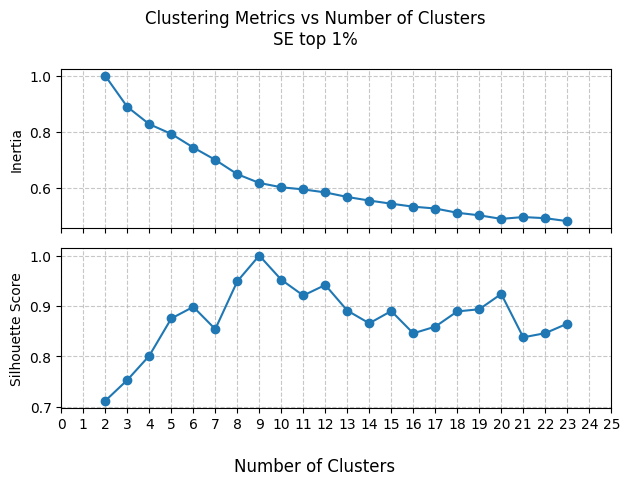

## Train and save

```python
start_time = time.perf_counter()
kmeans_model = KMeans(n_clusters=n_clusters, random_state=0).fit(
    xai_dict["norm_unique_weights"]
)
end_time = time.perf_counter()
print(f"train time: {end_time - start_time:.2f} seconds")

# save the model
joblib.dump(kmeans_model, f"{kmeans_model_dir}/kmeans_model.joblib")
```

```python
# train time: 0.05 seconds
# ['/home/elom/phd/code/clustering/bin_03/mse/kmeans_9_clusters_221_segments/kmeans_model.joblib']
```

## Save metadata

```python
kmeans_model = joblib.load(f"{kmeans_model_dir}/kmeans_model.joblib")

cluster_meta_df = meta_with_ratios_df.loc[specobjids_array].copy()
cluster_meta_df["cluster"] = kmeans_model.labels_

cluster_meta_df.to_csv(f"{kmeans_model_dir}/metadata.csv.gz", compression="gzip")
```

# Clusters metadata

In [20]:
kmeans_model = joblib.load(f"{kmeans_model_dir}/kmeans_model.joblib")
cluster_labels = kmeans_model.labels_

# get spectra and weights per cluster
spectra_cluster_dict, weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=xai_dict["norm_weights"],
    print_n_clusters=True,
)

xai_dict["spectra_cluster_dict"] = spectra_cluster_dict
xai_dict["weights_cluster_dict"] = weights_cluster_dict

_, unique_weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=xai_dict["norm_unique_weights"],
    print_n_clusters=False,
)

xai_dict["unique_weights_cluster_dict"] = unique_weights_cluster_dict
centroids = kmeans_model.cluster_centers_
xai_dict["centroids"] = centroids

# 0;165
# 1;295
# 2;232
# 3;59
# 4;177
# 5;211
# 6;45
# 7;346
# 8;289

0;165
1;295
2;232
3;59
4;177
5;211
6;45
7;346
8;289


In [ ]:
cluster_meta_df = pd.read_csv(
    f"{kmeans_model_dir}/metadata.csv.gz", index_col="specobjid"
)
cluster_meta_df.shape

(1819, 52)

# Avg Spec & Explanations

In [22]:
# for clustering library compatibility
# n_segments -= 1

for label, centroid in enumerate(xai_dict["centroids"]):

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=None,
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    centroid = clustering.expand_weights_per_segments(
        centroid.reshape(1, -1),
        wave_nm.size,
        n_segments,
    )

    centroid = centroid.reshape(-1)
    avg_spectrum = spectra_cluster_dict[label].mean(axis=0)

    axs[0].plot(wave_nm, avg_spectrum, color="black", label="Average spectrum")
    axs[0].legend()
    # weights
    axs[1].plot(wave_nm, centroid, color="black", label="Average explanation")
    axs[1].legend()
    # set limits
    axs[1].set_ylim(0, 1.1)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label}",
        fontsize=12,
    )

    plot_name = f"avg_spec_centroid_{label}"

    save_to = f"{kmeans_model_dir}/avg_spec_centroids"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

## Top ranked anomalies per cluster

In [23]:
cluster_id = 8

mask = cluster_meta_df["cluster"] == cluster_id
metadata_df = cluster_meta_df.loc[mask].copy()

spectra = anomalies_arr[mask]
norm_weights = xai_dict["norm_weights"][mask]

plot_top_ranked_explanations(
    cluster_id=cluster_id,
    metadata_df=metadata_df,
    spectra=spectra,
    norm_weights=norm_weights,
    wave=wave_nm,
    kmeans_model_dir=kmeans_model_dir,
    donwload_images=True,
    n_top_ranked=20,
    max_norm_weights=False,
)

Number of anomalies in cluster 8: 289
Explanation for anomaly rank 1
Explanation for anomaly rank 2
Explanation for anomaly rank 3
Explanation for anomaly rank 4
Explanation for anomaly rank 5
Explanation for anomaly rank 6
Explanation for anomaly rank 7
Explanation for anomaly rank 8
Explanation for anomaly rank 9
Explanation for anomaly rank 10
Explanation for anomaly rank 11
Explanation for anomaly rank 12
Explanation for anomaly rank 13
Explanation for anomaly rank 14
Explanation for anomaly rank 15
Explanation for anomaly rank 16
Explanation for anomaly rank 17
Explanation for anomaly rank 18
Explanation for anomaly rank 19
Explanation for anomaly rank 20
Explanation for anomaly rank 21


# Line ratios

In [24]:
lines_cols = [
    "h_alpha_flux",
    "h_beta_flux",
    "nii_6548_flux",
    "nii_6584_flux",
    "sii_6717_flux",
    "sii_6731_flux",
    "oii_3726_flux",
    "oii_3729_flux",
    "oiii_4959_flux",
    "oiii_5007_flux",
    "oiii_flux",
]
cluster_meta_df[lines_cols].describe()

,h_alpha_flux,h_beta_flux,nii_6548_flux,nii_6584_flux,sii_6717_flux,sii_6731_flux,oii_3726_flux,oii_3729_flux,oiii_4959_flux,oiii_5007_flux,oiii_flux
count,1.781000e+03,1.785000e+03,1.780000e+03,1.780000e+03,1.750000e+03,1.757000e+03,1.376000e+03,1.388000e+03,1.748000e+03,1.794000e+03,1.794000e+03
mean,1.291045e+07,3.508344e+06,1.532237e+06,4.621580e+06,7.801723e+06,1.705464e+08,7.357351e+06,3.106570e+07,2.131971e+06,2.247704e+06,2.256463e+06
std,5.432590e+08,1.482067e+08,6.463868e+07,1.949651e+08,2.404092e+08,7.093284e+09,1.780755e+08,9.342122e+08,6.624373e+07,9.512768e+07,9.552584e+07
min,2.159138e-01,2.652776e-01,3.730642e-02,1.125248e-01,2.467343e-01,5.699907e-02,6.603864e-02,1.392909e-01,2.608672e-02,4.893990e-02,7.010176e-02
25%,6.398634e+02,1.688366e+02,4.099451e+01,1.236489e+02,1.149903e+02,8.402688e+01,1.258799e+02,1.250825e+02,6.955962e+01,1.854379e+02,1.888304e+02
50%,1.226268e+03,3.200270e+02,9.518348e+01,2.870953e+02,1.897278e+02,1.434133e+02,3.292063e+02,3.128883e+02,1.917229e+02,5.597372e+02,5.639956e+02
75%,2.169182e+03,5.732670e+02,1.910500e+02,5.762510e+02,2.935152e+02,2.257452e+02,6.064615e+02,5.948613e+02,4.641363e+02,1.374444e+03,1.385436e+03
max,2.292654e+10,6.261624e+09,2.727109e+09,8.225589e+09,9.422665e+09,2.973184e+11,6.080421e+09,3.417483e+10,2.468186e+09,4.029195e+09,4.046059e+09


In [25]:
n_nans = cluster_meta_df[lines_cols].isna().sum()
n_negatives = (cluster_meta_df[lines_cols] < 0).sum()
n_zeros = (cluster_meta_df[lines_cols] == 0).sum()
temp_df = pd.DataFrame(
    {"n_nans": n_nans, "n_negatives": n_negatives, "n_zeros": n_zeros}
)
temp_df.index.name = "line_flux_column"
temp_df = temp_df.reset_index()
temp_df

,line_flux_column,n_nans,n_negatives,n_zeros
0,h_alpha_flux,38,0,0
1,h_beta_flux,34,0,0
2,nii_6548_flux,39,0,0
3,nii_6584_flux,39,0,0
4,sii_6717_flux,69,0,0
5,sii_6731_flux,62,0,0
6,oii_3726_flux,443,0,0
7,oii_3729_flux,431,0,0
8,oiii_4959_flux,71,0,0
9,oiii_5007_flux,25,0,0


In [26]:
# Compute deciles (10th to 90th percentiles) for each column
deciles = np.arange(0.01, 1.01, 0.01)
decile_df = cluster_meta_df[lines_cols].quantile(q=deciles).T

decile_df.columns = [f"{int(q * 100)}th" for q in deciles]
decile_df

,1th,2th,3th,4th,5th,6th,6th,8th,9th,10th,...,91th,92th,93th,94th,95th,96th,97th,98th,99th,100th
h_alpha_flux,7.186355,13.157498,19.450760,29.612028,40.193440,46.510388,71.043828,116.452440,161.345000,190.381800,...,3599.469400,3846.327400,4064.999000,4276.028800,4563.04700,4923.448400,5616.690600,6328.288600,9.506428e+03,2.292654e+10
h_beta_flux,3.192283,6.065466,8.108324,11.901589,15.416896,19.879935,28.937306,40.588583,47.788423,56.451372,...,946.568296,1008.337440,1056.555080,1105.082080,1176.78460,1291.608760,1408.059160,1583.590440,2.033350e+03,6.261624e+09
nii_6548_flux,1.145356,2.537455,4.865596,6.766799,8.663868,11.029167,12.613179,13.998558,15.304941,16.852802,...,363.588372,380.724308,413.853928,434.724770,471.72010,533.566256,624.372049,768.638014,1.080633e+03,2.727109e+09
nii_6584_flux,3.454659,7.653549,14.675759,20.410229,26.132225,33.266513,38.044253,42.222872,46.163228,50.831954,...,1096.666530,1148.352240,1248.278900,1311.230680,1422.81640,1609.358760,1883.250440,2318.389640,3.259439e+03,8.225589e+09
sii_6717_flux,2.774752,7.488518,11.228410,14.136161,19.954653,25.742632,30.403707,37.923572,44.504381,50.169220,...,453.056918,476.753868,511.149692,536.308660,573.54093,620.136584,694.086372,771.415570,9.281405e+02,9.422665e+09
sii_6731_flux,2.164968,4.558868,7.537006,9.721090,11.669834,17.021521,19.746001,25.662376,29.685566,34.352728,...,360.779160,381.469956,393.693780,414.041916,462.34430,495.044180,553.383856,631.824104,7.371659e+02,2.973184e+11
oii_3726_flux,1.831006,4.729134,7.358460,10.310610,12.539265,16.518030,20.287822,24.176480,33.612927,38.161830,...,1049.099250,1120.276000,1222.667000,1289.078000,1522.91875,1713.551000,3038.595250,51454.200000,1.587074e+06,6.080421e+09
oii_3729_flux,1.464711,3.497100,8.449882,12.436703,15.356618,18.114603,21.671380,25.816385,28.436988,33.214032,...,957.831093,987.324932,1080.277120,1164.553320,1243.50700,1363.625840,1637.961150,2629.529060,3.013391e+06,3.417483e+10
oiii_4959_flux,1.226341,2.545225,3.551934,4.722751,6.321681,7.858709,9.217118,10.928372,13.474827,14.858188,...,926.298568,974.952536,1060.823500,1135.842560,1283.02295,1440.054880,1588.837500,1796.426980,2.323907e+03,2.468186e+09
oiii_5007_flux,2.636009,4.497255,6.803244,9.573504,11.984393,14.025011,16.391192,19.346630,24.520537,29.119260,...,2749.635790,2916.897320,3160.377360,3426.552060,3825.57895,4264.555920,4889.054480,5471.409360,7.176033e+03,4.029195e+09


In [27]:
# replace 0 with NaN
cluster_meta_df[lines_cols] = cluster_meta_df[lines_cols].replace(0, np.nan)
# replace negative fluxes numeric values with NaN
cluster_meta_df[lines_cols] = cluster_meta_df[lines_cols].where(
    cluster_meta_df[lines_cols] >= 0, np.nan
)
n_zeros = (cluster_meta_df[lines_cols] == 0).sum()
n_negatives = (cluster_meta_df[lines_cols] < 0).sum()
temp_df = pd.DataFrame({"n_negatives": n_negatives, "n_zeros": n_zeros})
temp_df.index.name = "line_flux_column"
temp_df = temp_df.reset_index()
temp_df

,line_flux_column,n_negatives,n_zeros
0,h_alpha_flux,0,0
1,h_beta_flux,0,0
2,nii_6548_flux,0,0
3,nii_6584_flux,0,0
4,sii_6717_flux,0,0
5,sii_6731_flux,0,0
6,oii_3726_flux,0,0
7,oii_3729_flux,0,0
8,oiii_4959_flux,0,0
9,oiii_5007_flux,0,0


# Median line ratios

In [28]:
df, ratio_cols = astronomy.compute_emission_line_ratios(cluster_meta_df)
range_n_clusters = range(0, n_clusters)

median_cluster_ratios_df = pd.DataFrame(
    index=range_n_clusters,
    columns=ratio_cols,
)
for cluster_id in range_n_clusters:

    mask = df["cluster"] == cluster_id

    median_cluster_ratios_df.loc[cluster_id, "balmer_decrement"] = np.nanmedian(
        df.loc[mask, "balmer_decrement"]
    )
    median_cluster_ratios_df.loc[cluster_id, "nii_to_halpha"] = np.nanmedian(
        df.loc[mask, "nii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_hbeta"] = np.nanmedian(
        df.loc[mask, "oiii_to_hbeta"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_oii"] = np.nanmedian(
        df.loc[mask, "oiii_to_oii"]
    )
    median_cluster_ratios_df.loc[cluster_id, "o3n2_index"] = np.nanmedian(
        df.loc[mask, "o3n2_index"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_to_halpha"] = np.nanmedian(
        df.loc[mask, "sii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_density_ratio"] = np.nanmedian(
        df.loc[mask, "sii_density_ratio"]
    )

median_cluster_ratios_df

,balmer_decrement,nii_to_halpha,oiii_to_hbeta,oiii_to_oii,o3n2_index,sii_to_halpha,sii_density_ratio
0,3.873793,0.619045,1.280006,1.029713,0.241105,0.407468,1.325033
1,3.701347,0.18913,1.855146,1.607732,0.95537,0.236419,1.366256
2,3.391788,0.24742,0.989048,0.822341,0.58316,0.304136,1.419293
3,4.169386,0.606644,3.421124,4.330869,0.809128,0.324378,1.255274
4,3.323971,0.174363,1.564551,1.108176,0.967622,0.282171,1.385621
5,4.09098,0.546082,1.01418,0.934328,0.341199,0.306759,1.231463
6,3.90782,0.404697,2.557174,2.914612,0.828289,0.288627,1.27311
7,3.859249,0.257472,1.338851,1.275116,0.68199,0.251719,1.33665
8,3.417836,0.114219,3.572165,3.281362,1.407514,0.217248,1.359457


In [29]:
percentiles = np.arange(0.45, 0.55, 0.01)
ratios_percentiles_df = df[ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,46th,47th,48th,49th,50th,51th,52th,53th,54th,55th
balmer_decrement,3.603107,3.620602,3.632930,3.647116,3.668969,3.679038,3.692443,3.709852,3.723891,3.741098,3.755085
nii_to_halpha,0.234838,0.239975,0.245432,0.250207,0.254902,0.259614,0.268189,0.277796,0.285090,0.290669,0.298330
oiii_to_hbeta,1.546710,1.601287,1.639899,1.694527,1.730276,1.772498,1.815691,1.847271,1.879173,1.925877,1.985341
oiii_to_oii,1.287236,1.312636,1.345774,1.372980,1.412035,1.458075,1.483448,1.509572,1.528156,1.544221,1.586794
o3n2_index,0.752555,0.765060,0.782803,0.798406,0.814355,0.837632,0.853038,0.866577,0.878822,0.891983,0.909533
sii_to_halpha,0.259456,0.261544,0.264104,0.266410,0.267988,0.269740,0.271213,0.273678,0.275551,0.277863,0.278859
sii_density_ratio,1.334871,1.336922,1.340285,1.344557,1.347186,1.349667,1.352247,1.355150,1.357635,1.359672,1.362148


## Cluster 0 ratios percentiles

In [31]:
cluster_mask = df["cluster"] == 0
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.515073,3.758697,3.873793,4.005841,4.133662
nii_to_halpha,0.534615,0.565365,0.619045,0.669871,0.701255
oiii_to_hbeta,0.928463,1.087507,1.280006,1.437370,1.622666
oiii_to_oii,0.835060,0.948211,1.029713,1.167229,1.274567
o3n2_index,0.089091,0.144614,0.241105,0.309759,0.332532
sii_to_halpha,0.344449,0.368734,0.407468,0.436757,0.467583
sii_density_ratio,1.222663,1.260913,1.325033,1.352056,1.380406


## Cluster 1 ratios percentiles

In [32]:
cluster_mask = df["cluster"] == 1
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.540763,3.635481,3.701347,3.762758,3.848921
nii_to_halpha,0.152103,0.169626,0.189130,0.216458,0.238300
oiii_to_hbeta,1.630599,1.717096,1.855146,2.022431,2.200085
oiii_to_oii,1.426605,1.534042,1.607732,1.760331,1.945840
o3n2_index,0.789667,0.874459,0.955370,1.018559,1.110525
sii_to_halpha,0.220255,0.228413,0.236419,0.244953,0.254198
sii_density_ratio,1.340528,1.352297,1.366256,1.373018,1.380393


## Cluster 2 percentiles

In [34]:
cluster_mask = df["cluster"] == 2
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.236855,3.335071,3.391788,3.448911,3.583262
nii_to_halpha,0.210246,0.234125,0.247420,0.264984,0.288051
oiii_to_hbeta,0.732330,0.857835,0.989048,1.137708,1.342814
oiii_to_oii,0.684629,0.739731,0.822341,0.933429,0.992763
o3n2_index,0.410183,0.505582,0.583160,0.639351,0.714869
sii_to_halpha,0.291068,0.296792,0.304136,0.314460,0.325069
sii_density_ratio,1.402034,1.413214,1.419293,1.434806,1.447467


## Cluster 3 ratios percentiles

In [35]:
cluster_mask = df["cluster"] == 3
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.995215,4.092025,4.169386,4.205840,4.251012
nii_to_halpha,0.509978,0.587494,0.606644,0.641684,0.653521
oiii_to_hbeta,2.781835,2.946282,3.421124,3.908730,4.560587
oiii_to_oii,3.403133,4.113640,4.330869,4.885393,4.990667
o3n2_index,0.754304,0.792608,0.809128,0.853809,0.870350
sii_to_halpha,0.303802,0.308837,0.324378,0.348800,0.372257
sii_density_ratio,1.200353,1.230722,1.255274,1.263863,1.285718


## Cluster 4 ratios percentiles

In [36]:
cluster_mask = df["cluster"] == 4
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.240596,3.288744,3.323971,3.362746,3.397244
nii_to_halpha,0.148659,0.162667,0.174363,0.182396,0.191291
oiii_to_hbeta,1.416762,1.484330,1.564551,1.765063,1.830140
oiii_to_oii,0.922980,1.006742,1.108176,1.170469,1.329345
o3n2_index,0.875645,0.912561,0.967622,1.038756,1.080539
sii_to_halpha,0.267804,0.275257,0.282171,0.290263,0.303921
sii_density_ratio,1.363332,1.374631,1.385621,1.397938,1.406091


## Cluster 5 percentiles

In [37]:
cluster_mask = df["cluster"] == 5
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.974783,4.036632,4.090980,4.193387,4.297377
nii_to_halpha,0.501397,0.520329,0.546082,0.594427,0.626612
oiii_to_hbeta,0.763518,0.873702,1.014180,1.128997,1.333868
oiii_to_oii,0.756446,0.841511,0.934328,1.087844,1.511221
o3n2_index,0.243393,0.293116,0.341199,0.377649,0.454515
sii_to_halpha,0.279113,0.288692,0.306759,0.324768,0.346337
sii_density_ratio,1.194658,1.221487,1.231463,1.253695,1.261957


## Cluster 6 percentiles

In [38]:
cluster_mask = df["cluster"] == 6
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.801349,3.861069,3.907820,3.944987,3.995912
nii_to_halpha,0.317407,0.337974,0.404697,0.478543,0.490195
oiii_to_hbeta,1.936460,2.220902,2.557174,3.316151,4.427758
oiii_to_oii,1.512442,2.111946,2.914612,3.500399,3.765755
o3n2_index,0.778420,0.780876,0.828289,0.866918,0.900271
sii_to_halpha,0.277477,0.286720,0.288627,0.309475,0.325315
sii_density_ratio,1.254650,1.265083,1.273110,1.280237,1.303657


## Cluster 7 percentiles

In [39]:
cluster_mask = df["cluster"] == 7
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.707166,3.794498,3.859249,3.958843,4.038941
nii_to_halpha,0.220457,0.243065,0.257472,0.281510,0.300476
oiii_to_hbeta,1.101740,1.210673,1.338851,1.441256,1.556081
oiii_to_oii,1.099797,1.174477,1.275116,1.372027,1.470996
o3n2_index,0.568284,0.616881,0.681990,0.746420,0.843575
sii_to_halpha,0.236985,0.244459,0.251719,0.259718,0.264814
sii_density_ratio,1.314805,1.323897,1.336650,1.346956,1.354667


## Cluster 8 percentiles

In [40]:
cluster_mask = df["cluster"] == 8
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.348700,3.385994,3.417836,3.475737,3.511063
nii_to_halpha,0.093929,0.104000,0.114219,0.126817,0.149330
oiii_to_hbeta,3.215574,3.388061,3.572165,3.729534,3.967582
oiii_to_oii,2.667759,2.942128,3.281362,3.682790,4.001187
o3n2_index,1.270617,1.323012,1.407514,1.454510,1.499491
sii_to_halpha,0.199979,0.208655,0.217248,0.228504,0.242921
sii_density_ratio,1.329806,1.346836,1.359457,1.369574,1.381969


# Redshift Analysis

In [42]:
z_dict = {"cluster": [], "z_min": [], "z_max": [], "z_mean": [], "z_median": []}

for cluster_id in range(0, n_clusters):

    mask = cluster_meta_df["cluster"] == cluster_id
    z = cluster_meta_df["z"].loc[mask].values

    z_dict["cluster"].append(cluster_id)
    z_dict["z_min"].append(np.min(z))
    z_dict["z_max"].append(np.max(z))
    z_dict["z_mean"].append(np.mean(z))
    z_dict["z_median"].append(np.median(z))
z_df = pd.DataFrame(z_dict)
z_df

,cluster,z_min,z_max,z_mean,z_median
0,0,0.016985,0.229779,0.094359,0.088040
1,1,0.010144,0.255615,0.062872,0.045290
2,2,0.010613,0.262315,0.067724,0.045686
3,3,0.073334,0.226657,0.117262,0.118017
4,4,0.011578,0.167272,0.046627,0.026706
5,5,0.011134,0.271920,0.081418,0.070973
6,6,0.105740,0.111085,0.108605,0.108540
7,7,0.010093,0.245340,0.068922,0.057455
8,8,0.010858,0.234167,0.052660,0.032587


In [43]:
low_wave, upper_wave = 5_565, 5_590
z_df["lower_wave_min"] = low_wave / (1 + z_df["z_min"])
z_df["upper_wave_min"] = upper_wave / (1 + z_df["z_min"])
z_df["lower_wave_max"] = low_wave / (1 + z_df["z_max"])
z_df["upper_wave_max"] = upper_wave / (1 + z_df["z_max"])
z_df["lower_wave_mean"] = low_wave / (1 + z_df["z_mean"])
z_df["upper_wave_mean"] = upper_wave / (1 + z_df["z_mean"])
z_df["lower_wave_median"] = low_wave / (1 + z_df["z_median"])
z_df["upper_wave_median"] = upper_wave / (1 + z_df["z_median"])
z_df

,cluster,z_min,z_max,z_mean,z_median,lower_wave_min,upper_wave_min,lower_wave_max,upper_wave_max,lower_wave_mean,upper_wave_mean,lower_wave_median,upper_wave_median
0,0,0.016985,0.229779,0.094359,0.088040,5472.056949,5496.639415,4525.203309,4545.532165,5085.170371,5108.014802,5114.703217,5137.680320
1,1,0.010144,0.255615,0.062872,0.045290,5509.114550,5533.863493,4432.089635,4452.000191,5235.815565,5259.336749,5323.880953,5347.797758
2,2,0.010613,0.262315,0.067724,0.045686,5506.557583,5531.295038,4408.565054,4428.369928,5212.021691,5235.435984,5321.863228,5345.770969
3,3,0.073334,0.226657,0.117262,0.118017,5184.781176,5208.073095,4536.720534,4557.101129,4980.925770,5003.301896,4977.560727,4999.921736
4,4,0.011578,0.167272,0.046627,0.026706,5501.307240,5526.021109,4767.525926,4788.943383,5317.079622,5340.965874,5420.248418,5444.598141
5,5,0.011134,0.271920,0.081418,0.070973,5503.724177,5528.448904,4375.274831,4394.930153,5146.020509,5169.138301,5196.211709,5219.554978
6,6,0.105740,0.111085,0.108605,0.108540,5032.828239,5055.437530,5008.618153,5031.118684,5019.823497,5042.374366,5020.117908,5042.670100
7,7,0.010093,0.245340,0.068922,0.057455,5509.396417,5534.146625,4468.658444,4488.733279,5206.177429,5229.565467,5262.635314,5286.276982
8,8,0.010858,0.234167,0.052660,0.032587,5505.223621,5529.955084,4509.113149,4529.369722,5286.607581,5310.356941,5389.377749,5413.588790
